Prepared data shape: (15000, 8)
Columns: ['timestamp', 'price', 'volume', 'signed_volume', 'liquidity', 'true_regime', 'log_price', 'ret_1']

Feature table head:
            timestamp  idx  target_future_vol  target_future_return  \
0 2025-01-01 01:06:40  800           0.007128              0.013041   
1 2025-01-01 01:08:20  820           0.008254             -0.018225   
2 2025-01-01 01:10:00  840           0.008767              0.020210   
3 2025-01-01 01:11:40  860           0.009251             -0.002320   
4 2025-01-01 01:13:20  880           0.008135              0.003143   

   target_continuation  past_vol  past_abs_ret_mean  past_return  \
0                    0  0.008066           0.006453    -0.036726   
1                    0  0.007735           0.006298     0.025275   
2                    0  0.007219           0.005922     0.022658   
3                    1  0.007184           0.005821     0.013041   
4                    1  0.008174           0.006130    -0.018225   

  

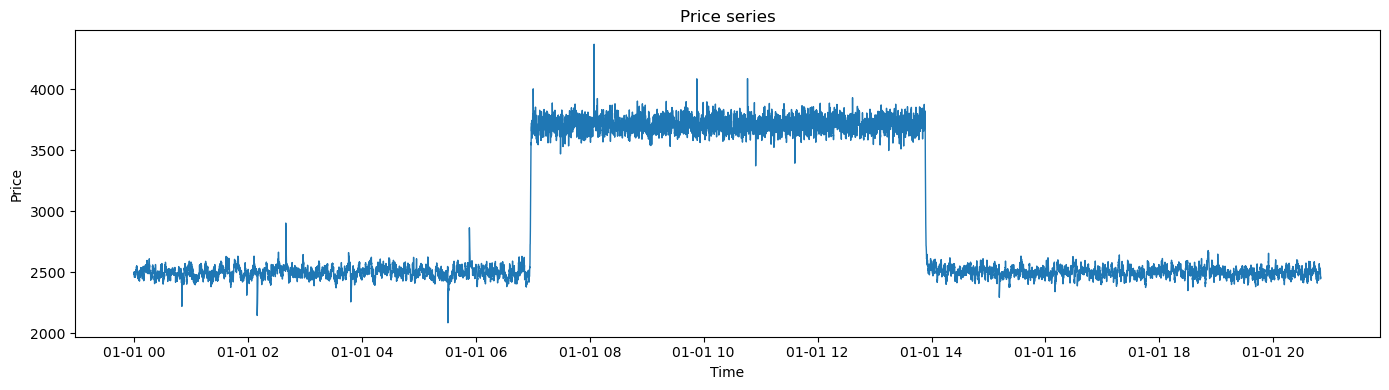

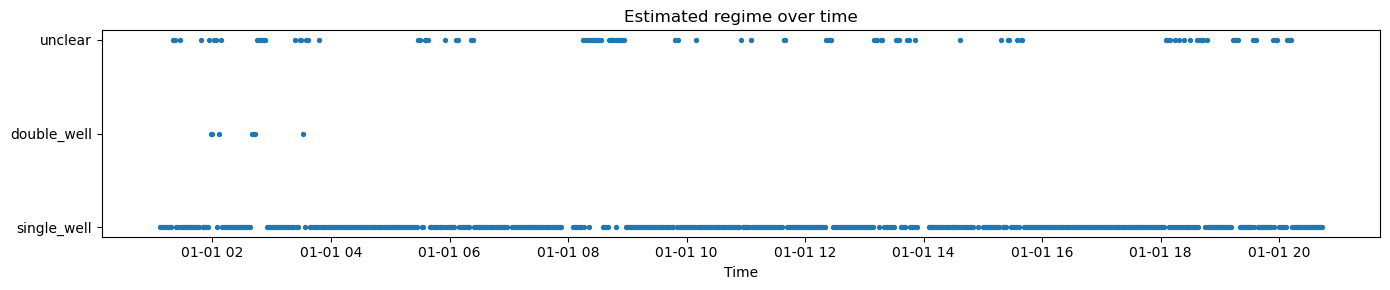

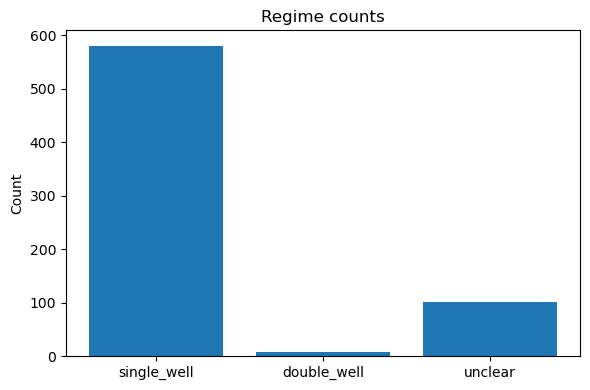

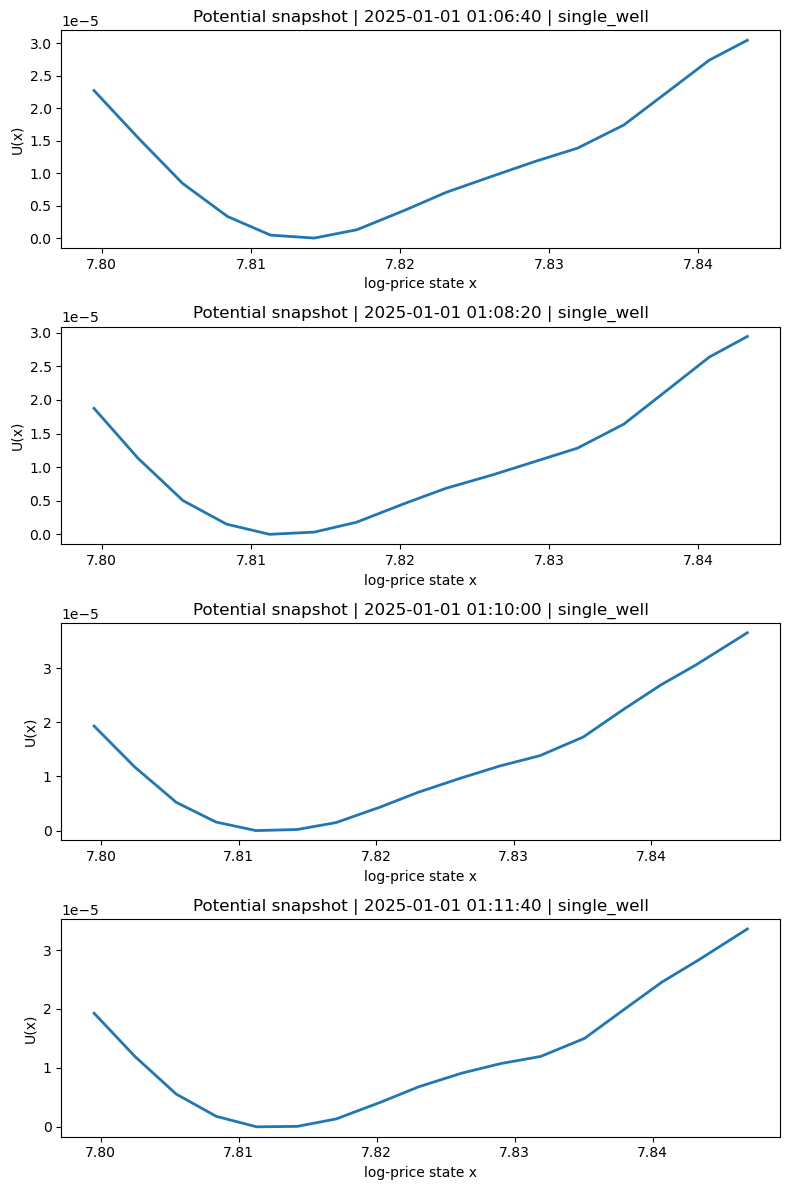

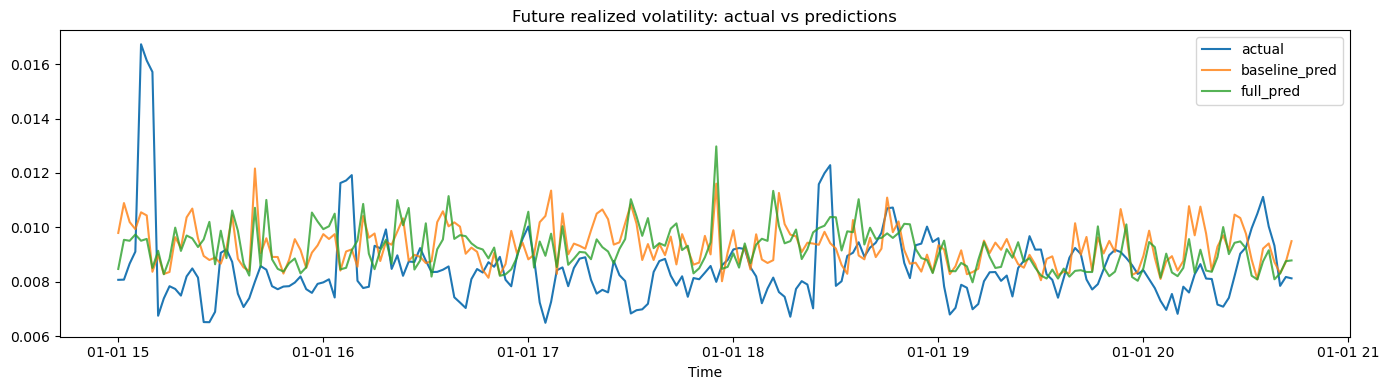

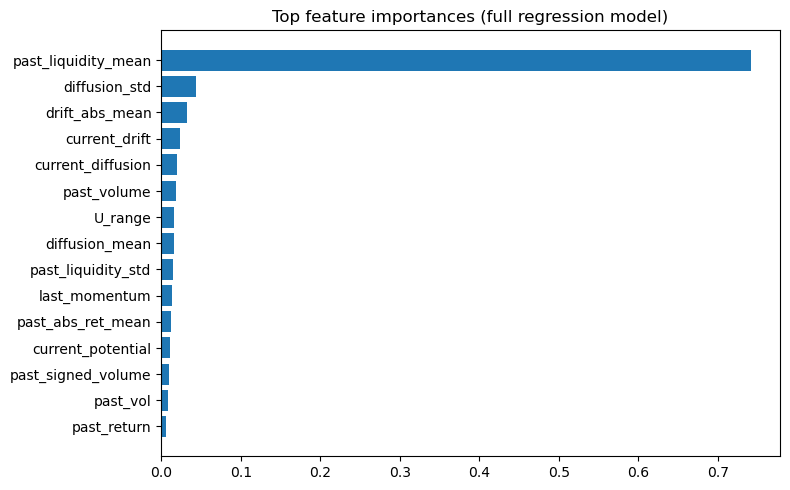


Saved:
 - metastability_features.pdf
 - metastability_model_results.pdf


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.backends.backend_pdf import PdfPages
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, roc_auc_score

# ============================================
# CONFIG
# ============================================
WINDOW = 800
STEP = 20
N_BINS = 25
MIN_BIN_COUNT = 20
FUTURE_HORIZON = 60
PAST_HORIZON = 60
RANDOM_STATE = 42

# ============================================
# SYNTHETIC DATA
# ============================================
def make_synthetic_amm_data(n=15000, seed=42):
    rng = np.random.default_rng(seed)
    ts = pd.date_range("2025-01-01", periods=n, freq="5s")

    x = np.zeros(n)
    regime = np.zeros(n, dtype=int)

    # 0 = single-well, 1 = double-well
    segments = [
        (0, n // 3, 0),
        (n // 3, 2 * n // 3, 1),
        (2 * n // 3, n, 0),
    ]
    for start, end, r in segments:
        regime[start:end] = r

    sigma_base = 0.01
    for t in range(1, n):
        xt = x[t - 1]
        r = regime[t]

        if r == 0:
            # Mean-reverting single-well dynamics
            mu = -0.12 * xt
            sigma = sigma_base * 0.8
        else:
            # Double-well dynamics
            a, b = 0.22, 1.4
            mu = a * xt - b * xt**3
            sigma = sigma_base * 1.3

        jump = rng.normal(0, 0.08) if rng.random() < 0.002 else 0.0
        x[t] = xt + mu + sigma * rng.normal() + jump

    price = np.exp(x) * 2500
    log_price = np.log(price)
    ret = np.diff(log_price, prepend=log_price[0])

    volume = np.exp(rng.normal(6.5 + 0.25 * regime, 0.6, n))
    signed_volume = np.sign(ret + 1e-12) * volume
    liquidity = 2_000_000 + 300_000 * (1 - regime) + rng.normal(0, 80_000, n)
    liquidity = np.maximum(liquidity, 100_000)

    df = pd.DataFrame({
        "timestamp": ts,
        "price": price,
        "volume": volume,
        "signed_volume": signed_volume,
        "liquidity": liquidity,
        "true_regime": np.where(regime == 0, "single_well", "double_well"),
    })
    return df

def load_data():
    return make_synthetic_amm_data()

# ============================================
# PREP
# ============================================
def prepare_df(df):
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.dropna(subset=["price"])
    df = df[df["price"] > 0].reset_index(drop=True)

    if "volume" not in df.columns:
        df["volume"] = 1.0
    df["volume"] = pd.to_numeric(df["volume"], errors="coerce").fillna(0.0).abs()

    if "signed_volume" not in df.columns:
        tmp_ret = np.log(df["price"]).diff().fillna(0.0)
        df["signed_volume"] = np.sign(tmp_ret.replace(0, np.nan)).fillna(0.0) * df["volume"]

    if "liquidity" not in df.columns:
        df["liquidity"] = df["volume"].rolling(200, min_periods=1).median().fillna(1.0)

    df["log_price"] = np.log(df["price"].astype(float))
    df["ret_1"] = df["log_price"].diff().fillna(0.0)

    df = df.drop_duplicates(subset=["timestamp"]).reset_index(drop=True)
    return df

# ============================================
# HELPERS
# ============================================
def rolling_realized_vol(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return np.nan
    return np.sqrt(np.mean(np.square(x)))

def cumtrapz_simple(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y, dtype=float)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    mids = 0.5 * (y[1:] + y[:-1]) * dx
    out[1:] = np.cumsum(mids)
    return out

def smooth_1d(arr, k=3):
    arr = np.asarray(arr, dtype=float)
    if len(arr) < k:
        return arr.copy()
    out = np.convolve(arr, np.ones(k) / k, mode="same")
    out[0] = np.mean(arr[:2])
    out[-1] = np.mean(arr[-2:])
    return out

def local_extrema(y):
    y = np.asarray(y, dtype=float)
    if len(y) < 3:
        return np.array([], dtype=int), np.array([], dtype=int)

    minima = []
    maxima = []
    for i in range(1, len(y) - 1):
        if y[i] < y[i - 1] and y[i] < y[i + 1]:
            minima.append(i)
        if y[i] > y[i - 1] and y[i] > y[i + 1]:
            maxima.append(i)
    return np.array(minima, dtype=int), np.array(maxima, dtype=int)

# ============================================
# KM / POTENTIAL ESTIMATION
# ============================================
def estimate_potential_features(x_window, eps=1e-12, n_bins=25, min_bin_count=20):
    x = np.asarray(x_window, dtype=float)
    dx = np.diff(x)
    x_prev = x[:-1]

    if len(x_prev) < max(n_bins * 3, 100):
        return None

    lo, hi = np.quantile(x_prev, [0.01, 0.99])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return None

    edges = np.linspace(lo, hi, n_bins + 1)
    bin_id = np.digitize(x_prev, edges) - 1

    centers = []
    drift = []
    diffusion = []
    counts = []

    for b in range(n_bins):
        mask = bin_id == b
        c = int(mask.sum())
        if c < min_bin_count:
            continue

        xv = x_prev[mask]
        dv = dx[mask]

        centers.append(np.mean(xv))
        drift.append(np.mean(dv))
        diffusion.append(np.mean(dv**2) + eps)
        counts.append(c)

    if len(centers) < 7:
        return None

    centers = np.asarray(centers)
    order = np.argsort(centers)
    centers = centers[order]
    drift = smooth_1d(np.asarray(drift)[order], k=3)
    diffusion = smooth_1d(np.asarray(diffusion)[order], k=3)

    # U(x) = - integral mu(x) dx
    U = -cumtrapz_simple(drift, centers)
    U = U - np.min(U)

    minima_idx, maxima_idx = local_extrema(U)
    U_range = float(np.max(U) - np.min(U) + eps)

    valid_minima = []
    for idx in minima_idx:
        left = U[max(0, idx - 1)]
        mid = U[idx]
        right = U[min(len(U) - 1, idx + 1)]
        if (left - mid > 0.02 * U_range) or (right - mid > 0.02 * U_range):
            valid_minima.append(idx)
    minima_idx = np.array(valid_minima, dtype=int)

    n_min = len(minima_idx)
    barrier_height = 0.0
    well_distance = 0.0
    asymmetry = 0.0
    current_x = x[-1]

    if n_min >= 2:
        mins_sorted = minima_idx[np.argsort(U[minima_idx])]
        i1, i2 = np.sort(mins_sorted[:2])
        well_distance = float(abs(centers[i2] - centers[i1]))
        segment = U[i1:i2 + 1]
        if len(segment) > 0:
            barrier_height = float(np.max(segment) - max(U[i1], U[i2]))
        asymmetry = float(abs(U[i1] - U[i2]))

    if n_min >= 2 and barrier_height > 0.08 * U_range:
        regime = "double_well"
    elif n_min == 1:
        regime = "single_well"
    else:
        regime = "unclear"

    idx_cur = int(np.argmin(np.abs(centers - current_x)))

    return {
        "regime": regime,
        "n_minima": int(n_min),
        "barrier_height": float(barrier_height),
        "well_distance": float(well_distance),
        "well_asymmetry": float(asymmetry),
        "U_range": float(U_range),
        "drift_abs_mean": float(np.mean(np.abs(drift))),
        "drift_sign_changes": int(np.sum(np.diff(np.sign(drift)) != 0)),
        "diffusion_mean": float(np.mean(diffusion)),
        "diffusion_std": float(np.std(diffusion)),
        "current_potential": float(U[idx_cur]),
        "current_drift": float(drift[idx_cur]),
        "current_diffusion": float(diffusion[idx_cur]),
        "current_x_center": float(centers[idx_cur]),
        "centers": centers,
        "U": U,
        "drift_curve": drift,
        "diff_curve": diffusion,
    }

# ============================================
# FEATURE TABLE
# ============================================
def build_feature_table(df, window=800, step=20, future_horizon=60, past_horizon=60):
    rows = []
    snapshots = []

    lp = df["log_price"].values
    ret = df["ret_1"].values
    vol = df["volume"].values
    svol = df["signed_volume"].values
    liq = df["liquidity"].values
    ts = df["timestamp"].values

    start = max(window, past_horizon)
    end = len(df) - future_horizon - 1

    for i in range(start, end, step):
        feat = estimate_potential_features(
            lp[i - window:i],
            n_bins=N_BINS,
            min_bin_count=MIN_BIN_COUNT
        )
        if feat is None:
            continue

        past_ret = ret[i - past_horizon:i]
        future_ret = ret[i + 1:i + 1 + future_horizon]
        last_mom = np.sum(ret[max(0, i - 5):i])

        rows.append({
            "timestamp": ts[i],
            "idx": i,

            # Targets
            "target_future_vol": rolling_realized_vol(future_ret),
            "target_future_return": float(lp[i + future_horizon] - lp[i]),
            "target_continuation": int(
                np.sign(last_mom + 1e-12) == np.sign(np.sum(future_ret) + 1e-12)
            ),

            # Baseline features
            "past_vol": rolling_realized_vol(past_ret),
            "past_abs_ret_mean": float(np.mean(np.abs(past_ret))),
            "past_return": float(lp[i] - lp[i - past_horizon]),
            "past_signed_volume": float(np.sum(svol[i - past_horizon:i])),
            "past_volume": float(np.sum(vol[i - past_horizon:i])),
            "past_liquidity_mean": float(np.mean(liq[i - past_horizon:i])),
            "past_liquidity_std": float(np.std(liq[i - past_horizon:i])),
            "last_momentum": float(last_mom),

            # Potential features
            "regime": feat["regime"],
            "regime_single": int(feat["regime"] == "single_well"),
            "regime_double": int(feat["regime"] == "double_well"),
            "regime_unclear": int(feat["regime"] == "unclear"),
            "n_minima": feat["n_minima"],
            "barrier_height": feat["barrier_height"],
            "well_distance": feat["well_distance"],
            "well_asymmetry": feat["well_asymmetry"],
            "U_range": feat["U_range"],
            "drift_abs_mean": feat["drift_abs_mean"],
            "drift_sign_changes": feat["drift_sign_changes"],
            "diffusion_mean": feat["diffusion_mean"],
            "diffusion_std": feat["diffusion_std"],
            "current_potential": feat["current_potential"],
            "current_drift": feat["current_drift"],
            "current_diffusion": feat["current_diffusion"],
        })

        if len(snapshots) < 6:
            snapshots.append({
                "timestamp": ts[i],
                "regime": feat["regime"],
                "centers": feat["centers"],
                "U": feat["U"],
                "drift_curve": feat["drift_curve"],
            })

    return pd.DataFrame(rows), snapshots

# ============================================
# MODELING
# ============================================
def train_test_split_time(df, frac=0.7):
    cut = int(len(df) * frac)
    return df.iloc[:cut].copy(), df.iloc[cut:].copy()

def safe_auc(y_true, y_prob):
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_prob))

def evaluate_models(features):
    features = features.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    train, test = train_test_split_time(features, frac=0.7)

    baseline_cols = [
        "past_vol",
        "past_abs_ret_mean",
        "past_return",
        "past_signed_volume",
        "past_volume",
        "past_liquidity_mean",
        "past_liquidity_std",
        "last_momentum",
    ]

    potential_cols = [
        "regime_single",
        "regime_double",
        "regime_unclear",
        "n_minima",
        "barrier_height",
        "well_distance",
        "well_asymmetry",
        "U_range",
        "drift_abs_mean",
        "drift_sign_changes",
        "diffusion_mean",
        "diffusion_std",
        "current_potential",
        "current_drift",
        "current_diffusion",
    ]

    Xb_train = train[baseline_cols]
    Xb_test = test[baseline_cols]
    Xf_train = train[baseline_cols + potential_cols]
    Xf_test = test[baseline_cols + potential_cols]

    # Regression
    y_train_reg = train["target_future_vol"]
    y_test_reg = test["target_future_vol"]

    reg_base = RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    reg_full = RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    reg_base.fit(Xb_train, y_train_reg)
    reg_full.fit(Xf_train, y_train_reg)

    pred_reg_base = reg_base.predict(Xb_test)
    pred_reg_full = reg_full.predict(Xf_test)

    # Classification
    y_train_clf = train["target_continuation"].astype(int)
    y_test_clf = test["target_continuation"].astype(int)

    clf_base = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    clf_full = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    clf_base.fit(Xb_train, y_train_clf)
    clf_full.fit(Xf_train, y_train_clf)

    pred_clf_base = clf_base.predict(Xb_test)
    pred_clf_full = clf_full.predict(Xf_test)
    prob_clf_base = clf_base.predict_proba(Xb_test)[:, 1]
    prob_clf_full = clf_full.predict_proba(Xf_test)[:, 1]

    results = pd.DataFrame([
        {
            "task": "future_vol_regression",
            "model": "baseline",
            "rmse": float(np.sqrt(mean_squared_error(y_test_reg, pred_reg_base))),
            "r2": float(r2_score(y_test_reg, pred_reg_base)),
            "accuracy": np.nan,
            "auc": np.nan,
        },
        {
            "task": "future_vol_regression",
            "model": "baseline_plus_potential",
            "rmse": float(np.sqrt(mean_squared_error(y_test_reg, pred_reg_full))),
            "r2": float(r2_score(y_test_reg, pred_reg_full)),
            "accuracy": np.nan,
            "auc": np.nan,
        },
        {
            "task": "continuation_classification",
            "model": "baseline",
            "rmse": np.nan,
            "r2": np.nan,
            "accuracy": float(accuracy_score(y_test_clf, pred_clf_base)),
            "auc": safe_auc(y_test_clf, prob_clf_base),
        },
        {
            "task": "continuation_classification",
            "model": "baseline_plus_potential",
            "rmse": np.nan,
            "r2": np.nan,
            "accuracy": float(accuracy_score(y_test_clf, pred_clf_full)),
            "auc": safe_auc(y_test_clf, prob_clf_full),
        },
    ])

    return {
        "train": train,
        "test": test,
        "results": results,
        "baseline_cols": baseline_cols,
        "potential_cols": potential_cols,
        "reg_full": reg_full,
        "pred_reg_base": pred_reg_base,
        "pred_reg_full": pred_reg_full,
    }

# ============================================
# PDF TABLE EXPORT
# ============================================
def save_df_to_pdf(df, filename, rows_per_page=25):
    out = df.copy()

    for col in out.columns:
        if pd.api.types.is_datetime64_any_dtype(out[col]):
            out[col] = out[col].astype(str)
        elif pd.api.types.is_numeric_dtype(out[col]):
            out[col] = out[col].map(lambda x: f"{x:.6g}" if pd.notnull(x) else "")
        else:
            out[col] = out[col].astype(str)

    n_rows = len(out)

    with PdfPages(filename) as pdf:
        if n_rows == 0:
            fig, ax = plt.subplots(figsize=(10, 2))
            ax.axis("off")
            ax.text(0.5, 0.5, "No rows to display", ha="center", va="center", fontsize=12)
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)
            return

        for start in range(0, n_rows, rows_per_page):
            end = min(start + rows_per_page, n_rows)
            chunk = out.iloc[start:end]

            fig_w = max(14, 0.55 * len(chunk.columns))
            fig_h = max(4, 0.33 * (len(chunk) + 3))

            fig, ax = plt.subplots(figsize=(fig_w, fig_h))
            ax.axis("off")

            table = ax.table(
                cellText=chunk.values,
                colLabels=chunk.columns,
                loc="center"
            )
            table.auto_set_font_size(False)
            table.set_fontsize(6)
            table.scale(1, 1.2)

            ax.set_title(
                f"{filename} | rows {start + 1}-{end} of {n_rows}",
                fontsize=10,
                pad=12
            )

            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

# ============================================
# PLOTTING
# ============================================
def plot_all(df, features, snapshots, payload):
    plt.figure(figsize=(14, 4))
    plt.plot(df["timestamp"], df["price"], linewidth=1)
    plt.title("Price series")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.tight_layout()
    plt.show()

    reg_map = {"single_well": 0, "double_well": 1, "unclear": 2}
    plt.figure(figsize=(14, 3))
    plt.scatter(features["timestamp"], features["regime"].map(reg_map), s=8)
    plt.yticks([0, 1, 2], ["single_well", "double_well", "unclear"])
    plt.title("Estimated regime over time")
    plt.xlabel("Time")
    plt.tight_layout()
    plt.show()

    counts = (
        features["regime"]
        .value_counts()
        .reindex(["single_well", "double_well", "unclear"])
        .fillna(0)
    )
    plt.figure(figsize=(6, 4))
    plt.bar(counts.index, counts.values)
    plt.title("Regime counts")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    n = min(4, len(snapshots))
    if n > 0:
        fig, axes = plt.subplots(n, 1, figsize=(8, 3 * n))
        if n == 1:
            axes = [axes]
        for ax, snap in zip(axes, snapshots[:n]):
            ax.plot(snap["centers"], snap["U"], linewidth=2)
            ax.set_title(f"Potential snapshot | {pd.to_datetime(snap['timestamp'])} | {snap['regime']}")
            ax.set_xlabel("log-price state x")
            ax.set_ylabel("U(x)")
        plt.tight_layout()
        plt.show()

    test = payload["test"]

    plt.figure(figsize=(14, 4))
    plt.plot(test["timestamp"], test["target_future_vol"].values, label="actual", linewidth=1.5)
    plt.plot(test["timestamp"], payload["pred_reg_base"], label="baseline_pred", alpha=0.8)
    plt.plot(test["timestamp"], payload["pred_reg_full"], label="full_pred", alpha=0.8)
    plt.legend()
    plt.title("Future realized volatility: actual vs predictions")
    plt.xlabel("Time")
    plt.tight_layout()
    plt.show()

    importances = pd.Series(
        payload["reg_full"].feature_importances_,
        index=payload["baseline_cols"] + payload["potential_cols"]
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 5))
    plt.barh(importances.index[::-1], importances.values[::-1])
    plt.title("Top feature importances (full regression model)")
    plt.tight_layout()
    plt.show()

# ============================================
# MAIN
# ============================================
df_raw = load_data()
df = prepare_df(df_raw)

print("Prepared data shape:", df.shape)
print("Columns:", list(df.columns))

features, snapshots = build_feature_table(
    df,
    window=WINDOW,
    step=STEP,
    future_horizon=FUTURE_HORIZON,
    past_horizon=PAST_HORIZON,
)

if len(features) < 200:
    raise ValueError(
        f"Too few feature rows ({len(features)}). "
        "Use more data, smaller WINDOW, smaller MIN_BIN_COUNT, or smaller STEP."
    )

print("\nFeature table head:")
print(features.head())

print("\nRegime distribution:")
print(features["regime"].value_counts(dropna=False))

payload = evaluate_models(features)

print("\nModel comparison:")
print(payload["results"])

plot_all(df, features, snapshots, payload)

save_df_to_pdf(features, "metastability_features.pdf", rows_per_page=25)
save_df_to_pdf(payload["results"], "metastability_model_results.pdf", rows_per_page=25)

print("\nSaved:")
print(" - metastability_features.pdf")
print(" - metastability_model_results.pdf")